In [3]:
#%config InlineBackend.figure_formats=['svg']
from os import listdir
import numpy as np

from ExistingAlgorithms.DRMetrics import matrix_metrics
from ExistingAlgorithms.Plot import plot_1D, plot_traces

from AutoencoderAPI.utils.compare import compare
from AutoencoderAPI.utils.kernelDensity import kernel_density
from AutoencoderAPI.loadAutoencoder import loadAutoencoder

from ExistingAlgorithms.MaxValue import max_value
from ExistingAlgorithms.Area import area
from ExistingAlgorithms.PCA import principal_component
from ExistingAlgorithms.SklearnAvailable import dimension_reduction

from sklearn.decomposition import PCA, KernelPCA, NMF
from sklearn.manifold import Isomap, TSNE, SpectralEmbedding, LocallyLinearEmbedding, MDS

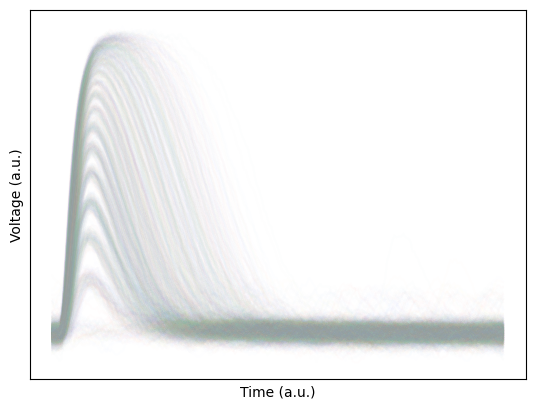

In [4]:
signal_size = 250
path_test = 'Datasets/NIST (250) test/'
path_train = 'Datasets/NIST (250) train/'

X_test = np.concatenate([np.fromfile(f"{path_test}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_test)])
X_test = X_test.astype("double")[::2]

X_train = np.concatenate([np.fromfile(f"{path_train}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_train)])
X_train = X_train.astype("double")[::2]

X = np.concatenate((X_test,X_train))
plot_traces(np.copy(X_test))

### Max Value

In [5]:
X_i_MAX, X_r_MAX, X_l_MAX = max_value(np.copy(X_test), filter=True)

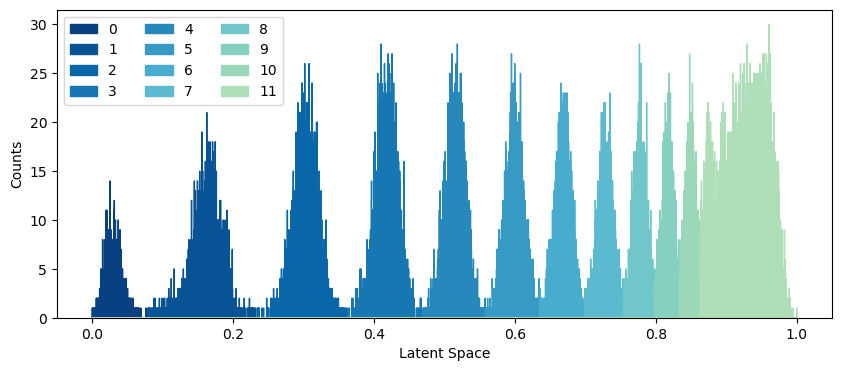

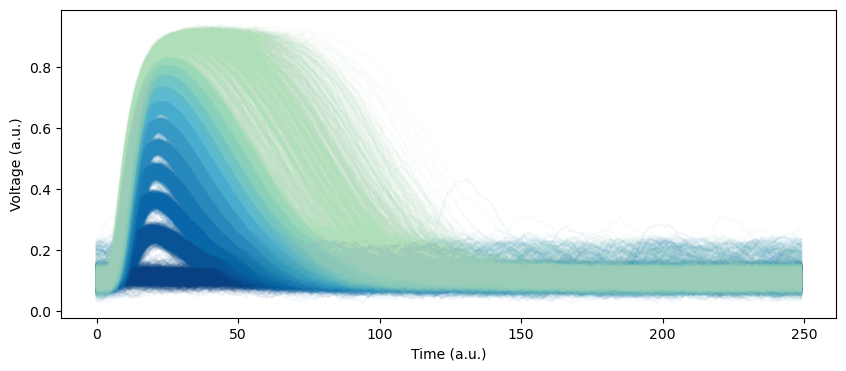

In [6]:
kd = kernel_density(X_l_MAX, bw=[0.01])
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))

### Area

In [7]:
X_i_AREA, X_r_AREA, X_l_AREA = area(np.copy(X_test), filter=True)

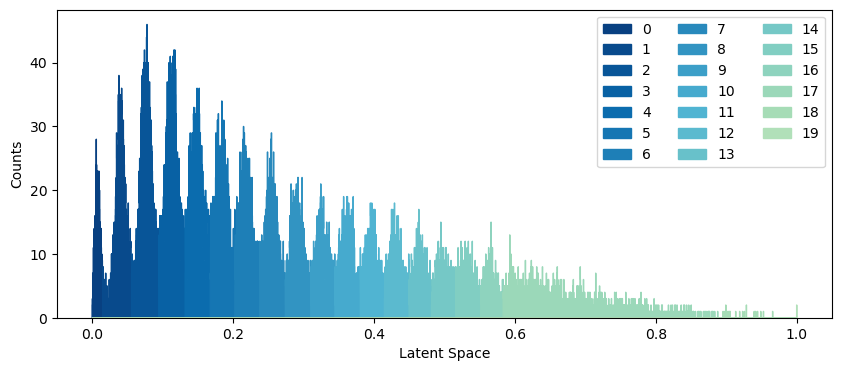

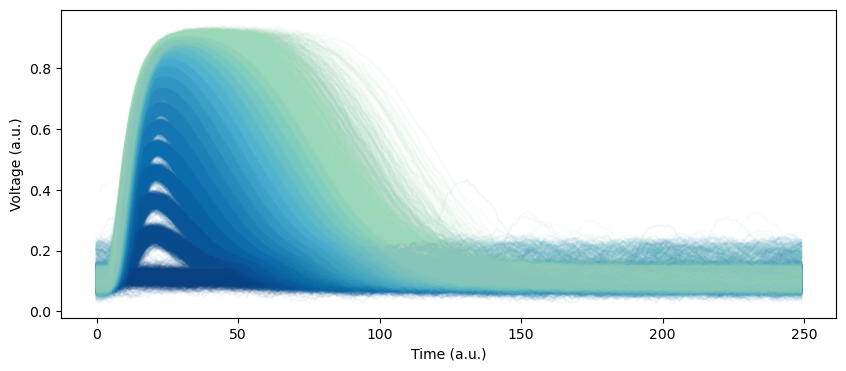

In [8]:
kd = kernel_density(X_l_AREA, bw=[0.01])
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))

### Principal Component Analysis (PCA)

In [9]:
X_i_PCA, X_r_PCA, X_l_PCA = dimension_reduction(np.copy(X_train),np.copy(X_test),PCA,n_components=1)

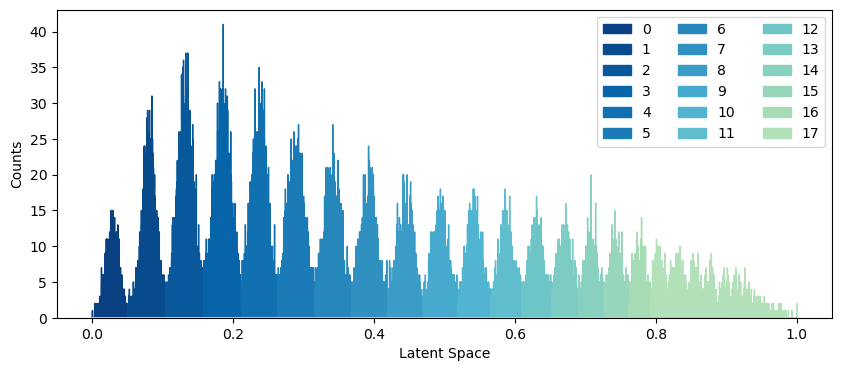

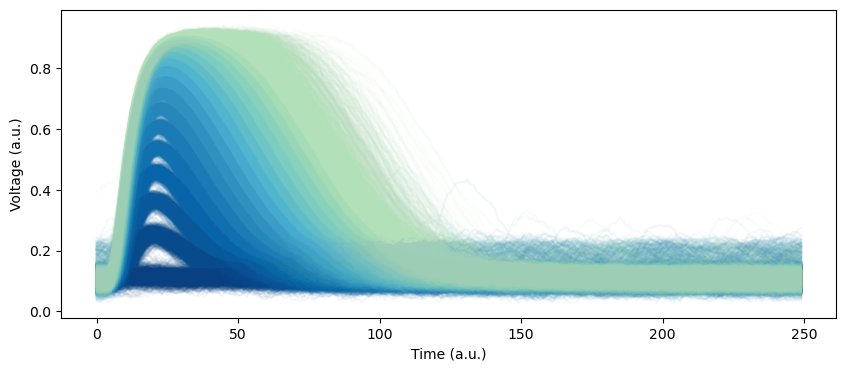

In [10]:
kd = kernel_density(X_l_PCA, bw=[0.01])
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))

### Kernel PCA (Polynomial)

In [11]:
X_i_KPCA_P, X_r_KPCA_P, X_l_KPCA_P = dimension_reduction(np.copy(X_train),np.copy(X_test),KernelPCA,n_components=1, kernel="poly", fit_inverse_transform=True)

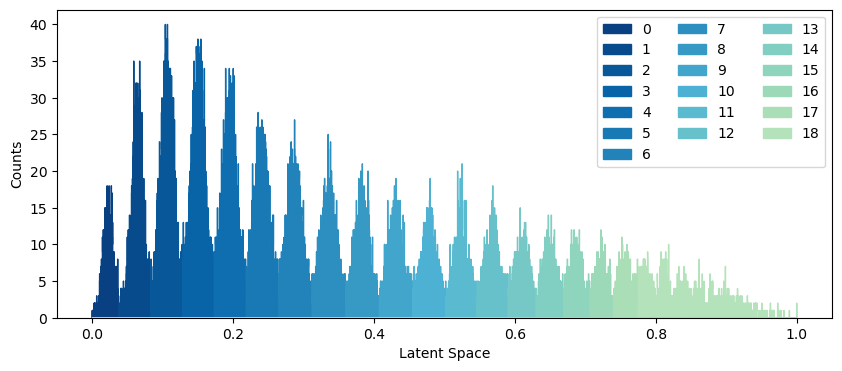

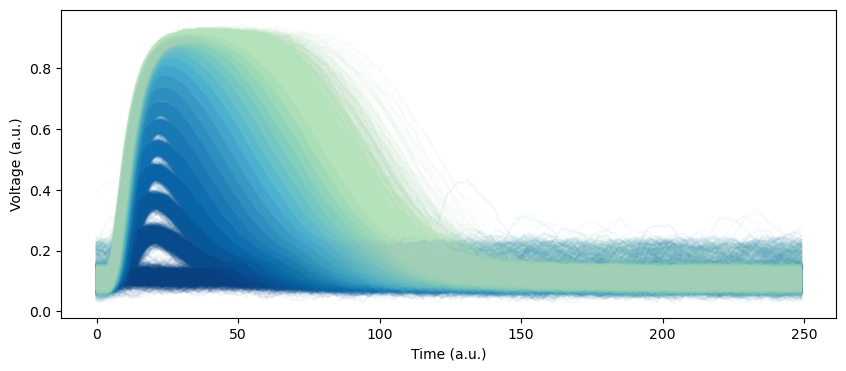

In [12]:
kd = kernel_density(X_l_KPCA_P, bw=[0.01])
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))

### Kernel PCA (Radial basis function)

In [13]:
X_i_KPCA_RBF, X_r_KPCA_RBF, X_l_KPCA_RBF = dimension_reduction(np.copy(X_train),np.copy(X_test),KernelPCA,n_components=1,kernel="rbf",gamma=0.02, fit_inverse_transform=True)

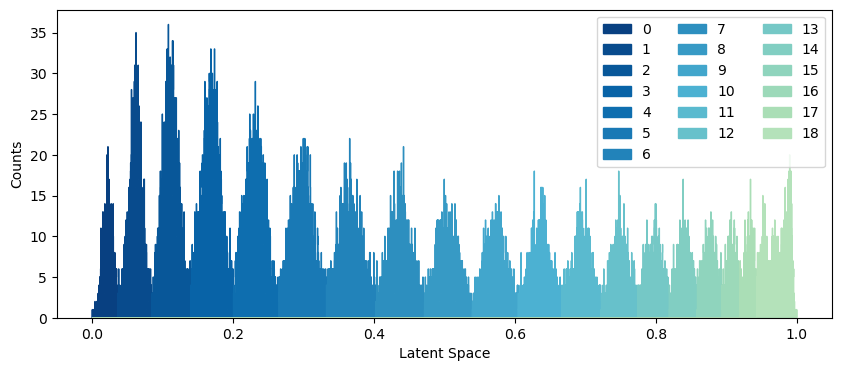

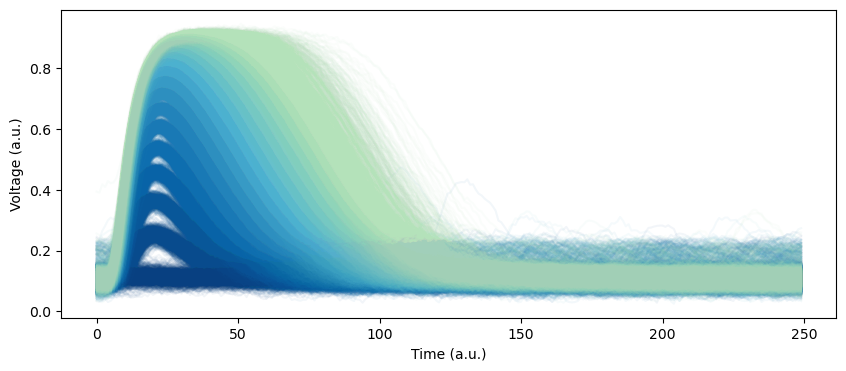

In [14]:
kd = kernel_density(X_l_KPCA_RBF, bw=[0.01])
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))

### Kernel PCA (Sigmoid)

In [15]:
X_i_KPCA_S, X_r_KPCA_S, X_l_KPCA_S = dimension_reduction(np.copy(X_train),np.copy(X_test),KernelPCA,n_components=1,kernel="sigmoid",gamma=0.02, fit_inverse_transform=True)

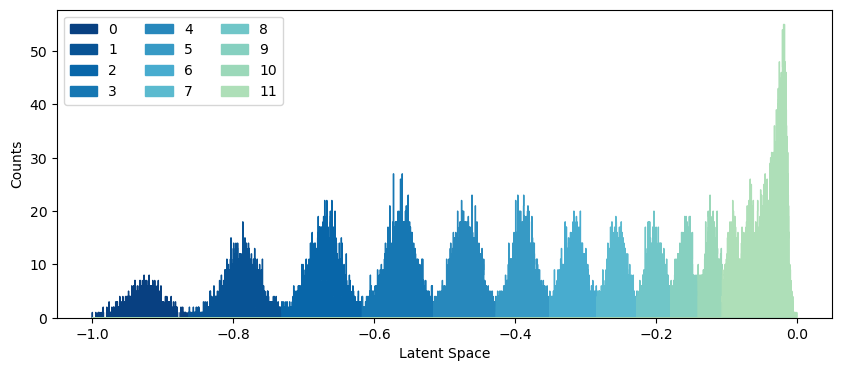

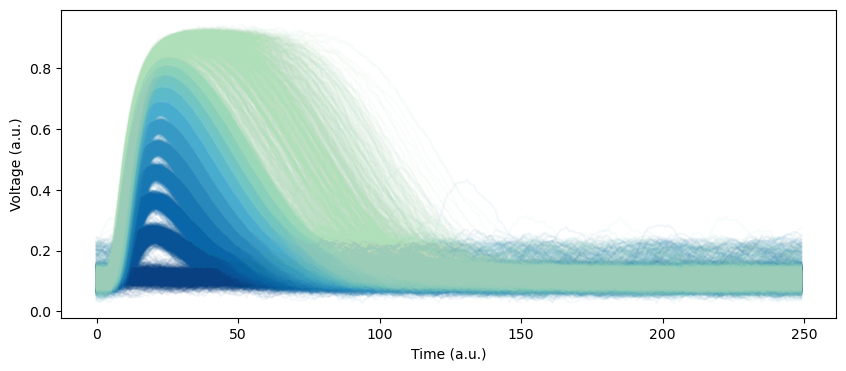

In [16]:
kd = kernel_density(X_l_KPCA_S, bw=[0.01], flip=True)
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))

### Kernel PCA (Cosine)

In [17]:
X_i_KPCA_C, X_r_KPCA_C, X_l_KPCA_C = dimension_reduction(np.copy(X_train),np.copy(X_test),KernelPCA,n_components=1,kernel="cosine",gamma=0.02, fit_inverse_transform=True)

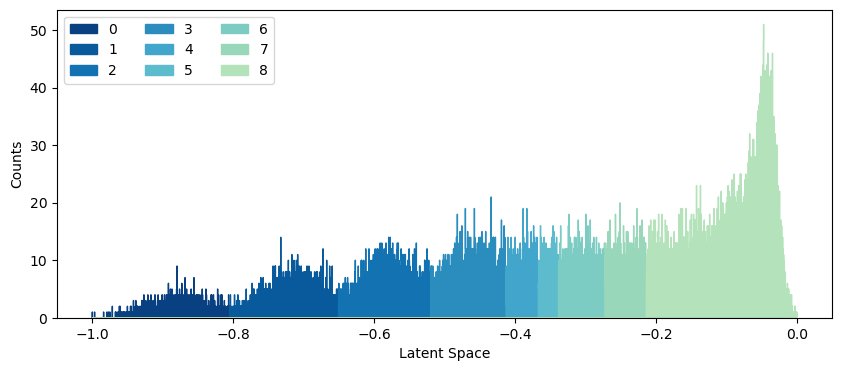

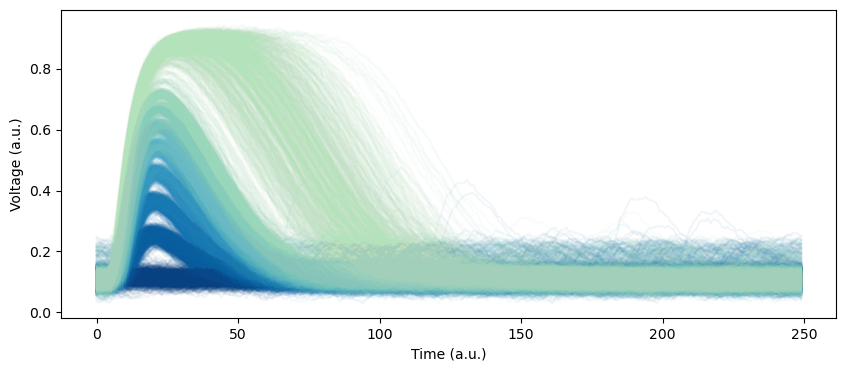

In [18]:
kd = kernel_density(X_l_KPCA_C, bw=[0.01], flip=True)
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))

### t-distributed Stochastic Neighbor Embedding (t-SNE)

In [19]:
X_i_TSNE, X_r_TSNE, X_l_TSNE = dimension_reduction(np.copy(X_train),np.copy(X_test),TSNE,n_components=1, perplexity=250)

'TSNE' object has no attribute 'transform'


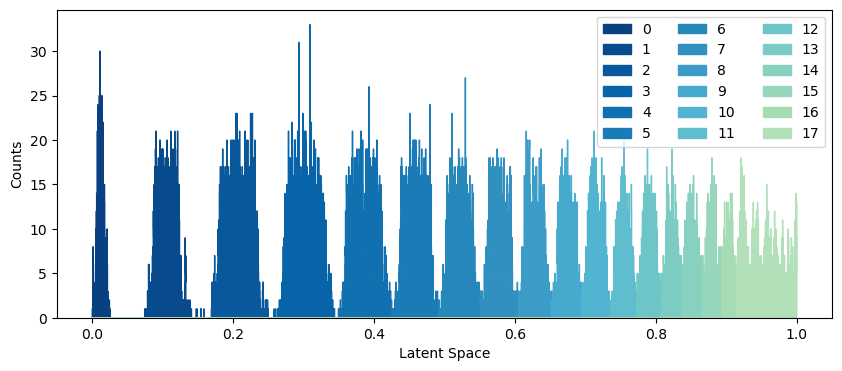

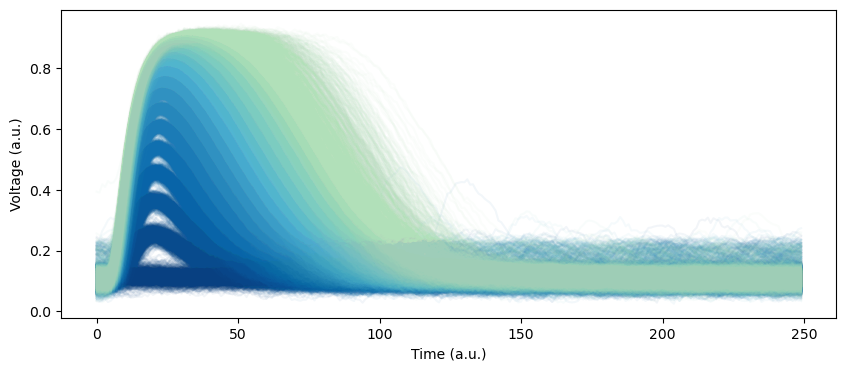

In [20]:
kd = kernel_density(X_l_TSNE, bw=[0.01])
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))

### Spectral Embedding 

In [21]:
#X_i_SE, X_r_SE, X_l_SE = dimension_reduction(np.copy(X),SpectralEmbedding,n_components=1)
#plot_1D(X_l_SE)

### Non-Negative Matrix Factorization (NMF)

In [22]:
X_i_NMF, X_r_NMF, X_l_NMF = dimension_reduction(np.copy(X_train),np.copy(X_test),NMF,n_components=1,alpha_W=0.1,random_state=42)

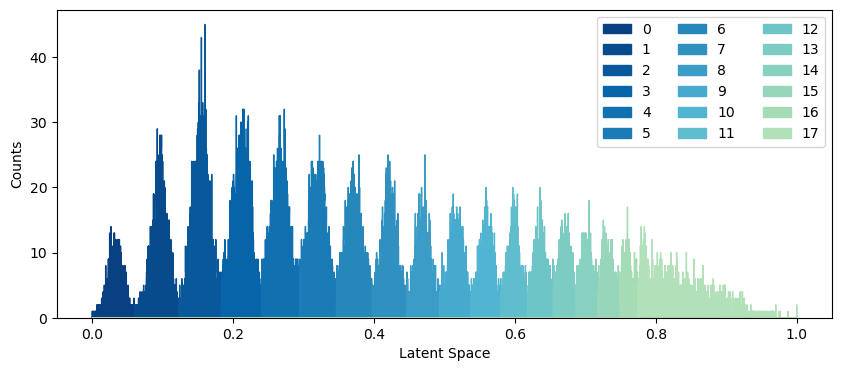

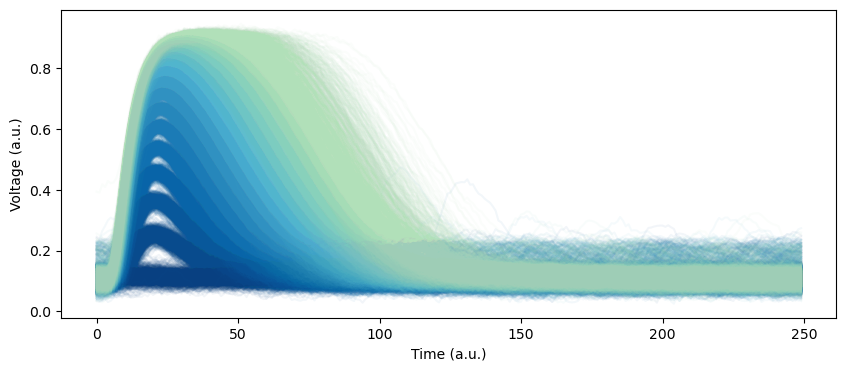

In [23]:
kd = kernel_density(X_l_NMF, bw=[0.01])
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))

### Isomap

In [24]:
X_i_ISO, X_r_ISO, X_l_ISO = dimension_reduction(np.copy(X_train),np.copy(X_test),Isomap,n_neighbors=20, n_components=1, eigen_solver="arpack")

'Isomap' object has no attribute 'inverse_transform'


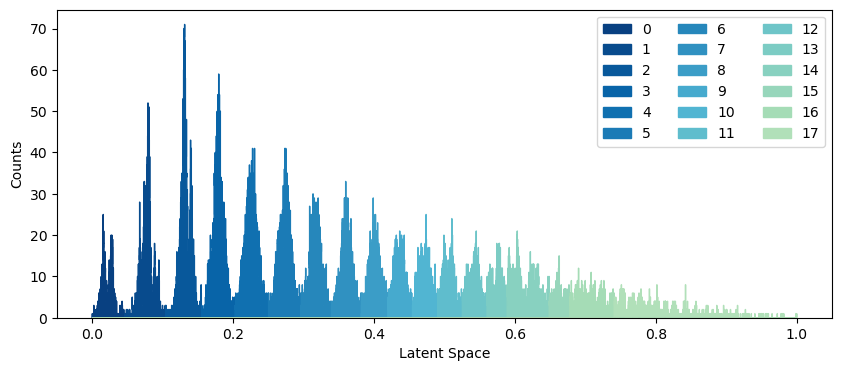

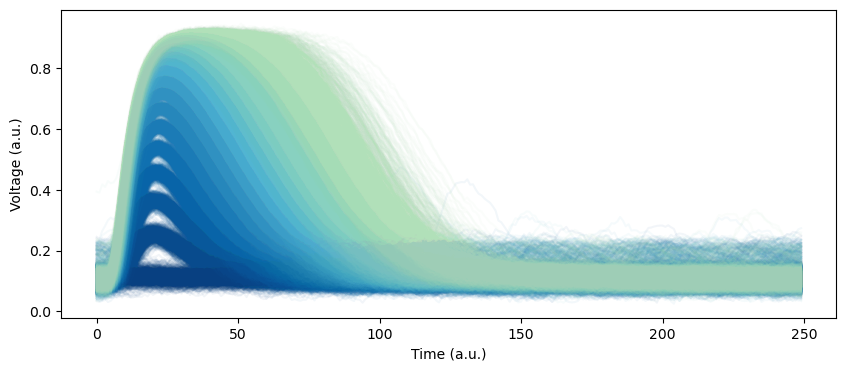

In [25]:
kd = kernel_density(X_l_ISO, bw=[0.01])
#kd.plot_density()
kd.plot_cluster()
kd.plot_traces(np.copy(X_test))

### Autoencoder



In [26]:
X_i_AUTO, X_r_AUTO, X_l_AUTO = loadAutoencoder(np.copy(X_test), 'AutoencoderLog/run-2023-10-10-09-19/fold 0', filter=False, flip=True)

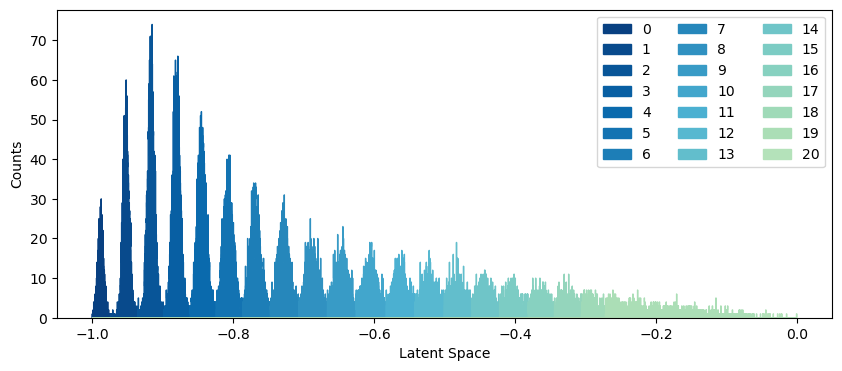

In [27]:
kd = kernel_density(X_l_AUTO, bw=[0.01])
#kd.plot_density()
kd.plot_cluster()
#kd.plot_traces(np.copy(X_test))

In [28]:
X_i_AUTOF, X_r_AUTOF, X_l_AUTOF = loadAutoencoder(np.copy(X_test), 'AutoencoderLog/run-2023-10-10-09-19/fold 0', filter=True, flip=True)

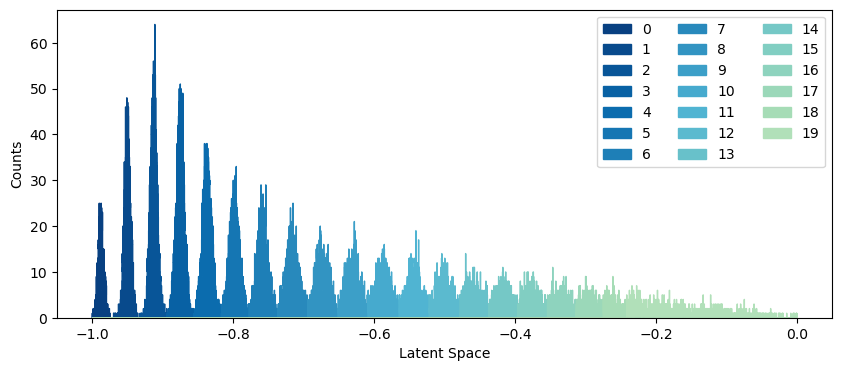

In [29]:
kd = kernel_density(X_l_AUTOF, bw=[0.01])
#kd.plot_density()
kd.plot_cluster()
#kd.plot_traces(np.copy(X_test))

In [30]:
i = [X_i_MAX, X_i_AREA, X_i_PCA, X_i_KPCA_P, 
     X_i_KPCA_RBF, X_i_KPCA_S, X_i_KPCA_C, X_i_NMF, 
     X_i_TSNE, X_i_ISO, 
      X_i_AUTO, X_i_AUTOF]
l = [X_l_MAX, X_l_AREA, X_l_PCA, X_l_KPCA_P, 
     X_l_KPCA_RBF, X_l_KPCA_S, X_l_KPCA_C, X_l_NMF, 
     X_l_TSNE, X_l_ISO, 
      X_l_AUTO, X_l_AUTOF]
r = [X_r_MAX, X_r_AREA, X_r_PCA, X_r_KPCA_P, 
     X_r_KPCA_RBF, X_r_KPCA_S, X_r_KPCA_C, X_r_NMF,
     X_r_TSNE, X_r_ISO, 
      X_r_AUTO, X_r_AUTOF]
methods = ['Max', 'Area', 'PCA', 'K-PCA (Polynomial)', 
           'K-PCA (RBF)', 'K-PCA (Sigmoid)', 
           'K-PCA (Cosine)', 'NMF', 't-SNE', 'Isomap',
           'Autoencoder', 'Autoencoder\nFiltered']
bw = [0.009, 0.009, 0.009, 0.009,
      0.009, 0.009, 0.015, 0.007, 0.009, 0.007,
      0.009, 0.007]

comp = compare(bw)
#comp.quality_metric_plot(i,r,l,methods, 40)